# How are in-demand skills trending for Data Analysts?
### Methology

1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demend

In [4]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

# Loading Data & Cleaning Up
df = pd.read_csv(r'C:\Users\LENOVO\Downloads\data_jobs.csv')
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [6]:
df_da_us= df[(df['job_country'] == 'United States') & (df['job_title'] == 'Data Analyst')].copy()


In [7]:
df_da_us['job_posted_month_no'] = df_da_us['job_posted_date'].dt.month

In [8]:
df_da_us_explode = df_da_us.explode('job_skills')

In [9]:
df_da_pivot = df_da_us_explode.pivot_table(index = 'job_posted_month_no', columns = 'job_skills', aggfunc = 'size', fill_value = 0)
df_da_pivot.loc['Total'] = df_da_pivot.sum()

In [10]:
df_da_pivot = df_da_pivot[df_da_pivot.loc['Total'].sort_values(ascending = False).index]

In [11]:
df_da_pivot.drop('Total', axis = 0, inplace = True)


In [12]:
df_da_pivot = df_da_pivot.iloc[:,0:4]

In [13]:
df_da_pivot

job_skills,sql,excel,tableau,python
job_posted_month_no,,,,
1,1138,781,646,529
2,782,544,408,378
3,802,580,463,400
4,845,577,462,421
5,706,490,367,336
6,742,491,395,396
7,560,431,296,292
8,784,641,480,460
9,485,336,277,253


In [14]:
df_da_pivot.columns

Index(['sql', 'excel', 'tableau', 'python'], dtype='str', name='job_skills')

In [15]:
da_total_skills_month = df_da_us.groupby('job_posted_month_no').size()

In [16]:
da_total_skills_month = da_total_skills_month.reset_index(name = 'skills_count')

In [17]:
da_pivot = pd.merge(df_da_pivot, da_total_skills_month, on = 'job_posted_month_no', how = 'left')

In [18]:
da_pivot_copy = da_pivot.copy()

In [19]:
da_pivot_copy

,job_posted_month_no,sql,excel,tableau,python,skills_count
0,1,1138,781,646,529,1816
1,2,782,544,408,378,1284
2,3,802,580,463,400,1362
3,4,845,577,462,421,1369
4,5,706,490,367,336,1156
5,6,742,491,395,396,1207
6,7,560,431,296,292,955
7,8,784,641,480,460,1414
8,9,485,336,277,253,856
9,10,556,343,308,270,1002


In [20]:
for k, v in enumerate(da_pivot.columns):
   if 0 < k < 5:
    da_pivot[f'{v}_percent'] = da_pivot_copy[v] / da_pivot_copy['skills_count']

In [21]:
da_pivot['job_posted_month'] = da_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format = '%m').strftime('%b'))
da_pivot.set_index('job_posted_month', inplace=True)
da_pivot = da_pivot.drop(columns = 'job_posted_month_no')

In [22]:
da_pivot

,sql,excel,tableau,python,skills_count,sql_percent,excel_percent,tableau_percent,python_percent
job_posted_month,,,,,,,,,
Jan,1138,781,646,529,1816,0.626652,0.430066,0.355727,0.291300
Feb,782,544,408,378,1284,0.609034,0.423676,0.317757,0.294393
Mar,802,580,463,400,1362,0.588840,0.425844,0.339941,0.293686
Apr,845,577,462,421,1369,0.617239,0.421476,0.337473,0.307524
May,706,490,367,336,1156,0.610727,0.423875,0.317474,0.290657
Jun,742,491,395,396,1207,0.614747,0.406794,0.327258,0.328086
Jul,560,431,296,292,955,0.586387,0.451309,0.309948,0.305759
Aug,784,641,480,460,1414,0.554455,0.453324,0.339463,0.325318
Sep,485,336,277,253,856,0.566589,0.392523,0.323598,0.295561


In [23]:
skills_percent = da_pivot.iloc[:,5:]

In [24]:
skills_percent

,sql_percent,excel_percent,tableau_percent,python_percent
job_posted_month,,,,
Jan,0.626652,0.430066,0.355727,0.291300
Feb,0.609034,0.423676,0.317757,0.294393
Mar,0.588840,0.425844,0.339941,0.293686
Apr,0.617239,0.421476,0.337473,0.307524
May,0.610727,0.423875,0.317474,0.290657
Jun,0.614747,0.406794,0.327258,0.328086
Jul,0.586387,0.451309,0.309948,0.305759
Aug,0.554455,0.453324,0.339463,0.325318
Sep,0.566589,0.392523,0.323598,0.295561


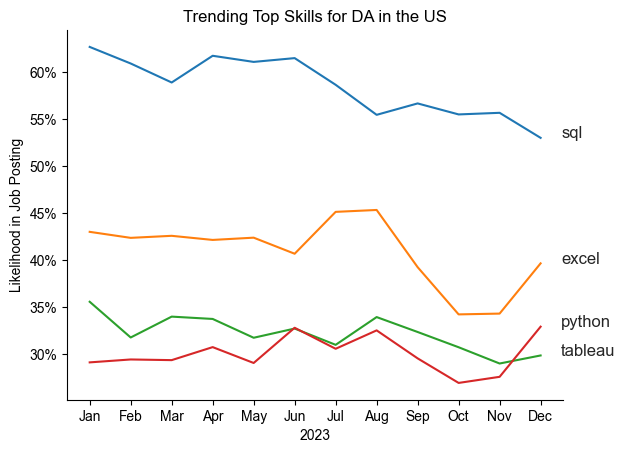

In [25]:
sns.lineplot(data = skills_percent, dashes = False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()
plt.title('Trending Top Skills for DA in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
from matplotlib.ticker import PercentFormatter, FuncFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
plt.legend().remove()

for i in range(4):
    plt.text(11.5, skills_percent.iloc[-1, i], f'{skills_percent.columns[i].replace('_percent','')}')
plt.show()